### Wind burst suite
In this notebook we run a suite of experiments with localized wind bursts. We use bursts of width 10 degrees in latitude and spacing 5 degrees in latitude.
Central latitudes will range from -50 to -10 degrees south, and we will look at western boundary thickness anomalies and transport anomalies in the South Atlantic.
The functional form of the wind bursts is as in `localized_bursts.ipynb`, with a strength of $\tau_0 = -0.001$, a longitudinal width of ten degrees, and a duration of one year. This suite of experiments aims to test the hypothesis that the magnitude of the thickness anomalies excited at the western boundary saturates at a certain latitude, as a single point of phase on the Rossby wave is no longer able to traverse a large extent of the wind anomaly.

#### Import / function definition cells

In [1]:
from pathlib import Path
from moc_adjustment_theory import EARTH_ROTATION_S, EARTH_RADIUS_M, GlobalRossbyModel, rossby_speed

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import xarray as xr

PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "data").is_dir() and (path / "notebooks").is_dir()
)
TEMPLATE_FORCING_PATH = (
    PROJECT_ROOT / "data/untracked/forcing/global_ERA5_SCOTIA_forcing.nc"
)

In [2]:
def zonal_wind_burst(
    tau_0: float,
    t_0: np.datetime64,
    t_1: np.datetime64,
    lat_0: float,
    lat_1: float,
    lon_0: float,
    lon_1: float,
    template_forcing_ds: xr.Dataset | None = None,
) -> xr.Dataset:
    """
    Create a zonal wind burst forcing dataset.

    Parameters
    ----------
    tau_0 : float
        Peak eastward kinematic wind-stress anomaly in m2 s-2. Negative
        values produce an easterly burst.
    t_0 : numpy.datetime64
        The start time of the wind burst.
    t_1 : numpy.datetime64
        The end time of the wind burst.
    lat_0 : float
        The southern latitude of the wind burst region.
    lat_1 : float
        The northern latitude of the wind burst region.
    lon_0 : float
        The western longitude of the wind burst region.
    lon_1 : float
        The eastern longitude of the wind burst region.
    template_forcing_ds : xr.Dataset, optional
        Dataset supplying the time, latitude, and longitude coordinates and
        forcing-variable metadata.
        If omitted, ``TEMPLATE_FORCING_PATH`` is opened long enough to load
        its one-dimensional coordinates.

    Returns
    -------
    xr.Dataset
        A lazily evaluated dataset containing ``M_Ek_x``, ``M_Ek_y``, and
        ``T_N`` on the template grid.

    Notes
    -----
    A single signed burst generally has a non-zero time mean. Pair it with
    a compensating forcing or explicitly relax the model's zero-mean check
    when that is the intended experiment.
    """
    if not np.isscalar(tau_0) or not np.isfinite(tau_0):
        raise ValueError("tau_0 must be a finite scalar")

    t_0 = np.datetime64(t_0, "ns")
    t_1 = np.datetime64(t_1, "ns")
    spatial_bounds = np.asarray([lat_0, lat_1, lon_0, lon_1], dtype=float)
    if np.isnat(t_0) or np.isnat(t_1):
        raise ValueError("t_0 and t_1 must be valid datetimes")
    if not np.all(np.isfinite(spatial_bounds)):
        raise ValueError("latitude and longitude bounds must be finite")
    if not (t_0 < t_1 and lat_0 < lat_1 and lon_0 < lon_1):
        raise ValueError("each lower burst bound must be less than its upper bound")
    if lon_1 - lon_0 > 360.0:
        raise ValueError("longitude interval must not exceed 360 degrees")

    if template_forcing_ds is None:
        with xr.open_dataset(TEMPLATE_FORCING_PATH) as source:
            template_forcing_ds = xr.Dataset(
                coords={
                    name: source.coords[name].load().copy(deep=True)
                    for name in ("time", "latitude", "longitude")
                },
                attrs=source.attrs.copy(),
            )
            template_variable_attrs = {
                name: source[name].attrs.copy()
                for name in ("M_Ek_x", "M_Ek_y", "T_N")
                if name in source
            }
    else:
        template_variable_attrs = {
            name: template_forcing_ds[name].attrs.copy()
            for name in ("M_Ek_x", "M_Ek_y", "T_N")
            if name in template_forcing_ds
        }

    missing = {"time", "latitude", "longitude"}.difference(
        template_forcing_ds.coords
    )
    if missing:
        raise ValueError(f"template dataset is missing coordinates: {sorted(missing)}")

    bounds = {
        "time": (t_0, t_1),
        "latitude": (float(lat_0), float(lat_1)),
        "longitude": (float(lon_0), float(lon_1)),
    }
    for name, (lower, upper) in bounds.items():
        coordinate = template_forcing_ds.coords[name]
        if coordinate.dims != (name,) or coordinate.size < 2:
            raise ValueError(f"{name} must be a one-dimensional coordinate")
        values = coordinate.values
        if np.any(np.diff(values) <= 0):
            raise ValueError(f"{name} coordinate must be strictly increasing")
        if name != "longitude" and (lower < values[0] or upper > values[-1]):
            raise ValueError(
                f"{name} bounds [{lower}, {upper}] lie outside the template range "
                f"[{values[0]}, {values[-1]}]"
            )

    def sine_bump(coordinate, lower, upper, chunk_size):
        phase = (coordinate - lower) / (upper - lower)
        envelope = xr.where(
            (coordinate > lower) & (coordinate < upper),
            np.sin(np.pi * phase)**2,
            0.0,
        )
        return envelope.astype(np.float32).chunk(
            {coordinate.dims[0]: min(chunk_size, coordinate.size)}
        )

    time_profile = sine_bump(template_forcing_ds.time, t_0, t_1, 12)
    latitude_profile = sine_bump(
        template_forcing_ds.latitude, lat_0, lat_1, 64
    )
    unwrapped_longitude = (
        (template_forcing_ds.longitude - lon_0) % 360.0 + lon_0
    )
    longitude_profile = sine_bump(unwrapped_longitude, lon_0, lon_1, 128)
    time_envelope, latitude_envelope, longitude_envelope = xr.broadcast(
        time_profile, latitude_profile, longitude_profile
    )
    burst_chunks = {"time": 12, "latitude": 64, "longitude": 128}
    tau_x = np.float32(tau_0)
    for envelope in (time_envelope, latitude_envelope, longitude_envelope):
        tau_x = tau_x * envelope.chunk(burst_chunks)

    coriolis = 2.0 * EARTH_ROTATION_S * np.sin(
        np.deg2rad(template_forcing_ds.latitude)
    )
    if lat_0 < 0.0 < lat_1:
        raise ValueError("a 1/f wind burst cannot cross the equator")
    active_latitude = (
        (template_forcing_ds.latitude > lat_0)
        & (template_forcing_ds.latitude < lat_1)
    )
    safe_coriolis = xr.where(active_latitude, coriolis, 1.0).chunk(
        {"latitude": min(64, coriolis.sizes["latitude"])}
    )

    m_ek_y = (-tau_x / safe_coriolis).astype(np.float32).rename("M_Ek_y")
    m_ek_x = xr.zeros_like(m_ek_y).rename("M_Ek_x")
    t_n = xr.zeros_like(time_profile, dtype=np.float64).rename("T_N")

    m_ek_x.attrs = template_variable_attrs.get("M_Ek_x", {
        "units": "m2 s-1",
        "long_name": "eastward Ekman transport anomaly",
        "positive": "eastward",
    })
    m_ek_y.attrs = template_variable_attrs.get("M_Ek_y", {
        "units": "m2 s-1",
        "long_name": "northward Ekman transport anomaly",
        "positive": "northward",
    })
    t_n.attrs = template_variable_attrs.get("T_N", {
        "units": "m3 s-1",
        "long_name": "total northern Atlantic transport anomaly",
        "positive": "northward",
        "latitude_degrees_north": 55.0,
    })

    forcing = xr.Dataset({"M_Ek_x": m_ek_x, "M_Ek_y": m_ek_y, "T_N": t_n})
    forcing = forcing.transpose(
        "time", "latitude", "longitude", missing_dims="ignore"
    )
    forcing.attrs = {
        "title": "Localized zonal wind-burst forcing",
        "kinematic_wind_stress_amplitude_m2_s2": float(tau_0),
        "EARTH_ROTATION_S_1": EARTH_ROTATION_S,
        "burst_start": np.datetime_as_string(t_0, unit="ns"),
        "burst_end": np.datetime_as_string(t_1, unit="ns"),
        "burst_latitude_bounds_degrees_north": [float(lat_0), float(lat_1)],
        "burst_longitude_bounds_degrees_east": [float(lon_0), float(lon_1)],
        "generated_by": "notebooks/wind_investigation/localized_bursts.ipynb",
    }
    return forcing

#### Setting up the suite

In [3]:
# basic parameters
lat_width = 10.0
lon_width = 10.0
central_lats = np.arange(-50.0, 0.0, 10.0)
central_lon = 0.0
lat_0 = central_lats - lat_width / 2
lat_1 = central_lats + lat_width / 2
lon_0 = central_lon - lon_width / 2
lon_1 = central_lon + lon_width / 2
tau_0 = -0.001
t_0 = np.datetime64("2005-01-01")
t_1 = np.datetime64("2006-01-01")
lon_width = 10.0
g = 0.02
isobath_ds = xr.open_dataset(PROJECT_ROOT / "data/tracked/isobath/global_isobath_GEBCO_1000m.nc").load()
H = isobath_ds.isobath_depth_m

In [4]:
# Build the eastern and western boundary traces
x_w = isobath_ds.x_wA.dropna("latitude").sortby("latitude", ascending=True)
x_eA = isobath_ds.x_eA.dropna("latitude").sortby("latitude", ascending=True)
y_I = x_eA.latitude.min()
x_eI = isobath_ds.x_eI.dropna("latitude").sortby("latitude", ascending=True).sel(latitude=slice(None, y_I)).isel(latitude=slice(None, -1))
y_P = x_eI.latitude.min()
x_eP = isobath_ds.x_eP.dropna("latitude").sortby("latitude", ascending=True).sel(latitude=slice(None, y_P)).isel(latitude=slice(None, -1))
x_e = xr.concat([x_eP, x_eI, x_eA], dim="latitude").sortby("latitude", ascending=True)
x_e = x_e.interp(latitude=x_w.latitude)
# Extract the travel times
L = EARTH_RADIUS_M * np.cos(np.radians(x_w.latitude)) * np.radians(x_e - x_w)
c = rossby_speed(L.latitude, g, H)
tt = L / c

In [5]:
bursts = [
        zonal_wind_burst(
        tau_0=tau_0,
        t_0=t_0,
        t_1=t_1,
        lat_0=l0,
        lat_1=l1,
        lon_0=lon_0,
        lon_1=lon_1,
    ) for l0, l1 in zip(lat_0, lat_1)
]

In [6]:
# construct the solutions
model = GlobalRossbyModel(isobath_ds, g_prime=g)
solutions = [
    model.solve(burst) for burst in bursts
]

#### Extracting and plotting diagnostics

In [7]:
# Extracting h_b for each of the bursts
h_b_list = [solution.h_b.sel(time=slice(t_0, "2016-01-01")).compute() for solution in solutions]

In [8]:
# Stitch south-to-north; keeping the last duplicate prioritizes the northern region.
atlantic_regions = ["atlantic_pacific", "atlantic_indian", "north_atlantic"]
h_b_list = [
    xr.concat([h_b.sel(region=r, drop=True).dropna("latitude", how="all") for r in atlantic_regions], dim="latitude")
    .drop_duplicates("latitude", keep="last").sortby("latitude")
    for h_b in h_b_list
]

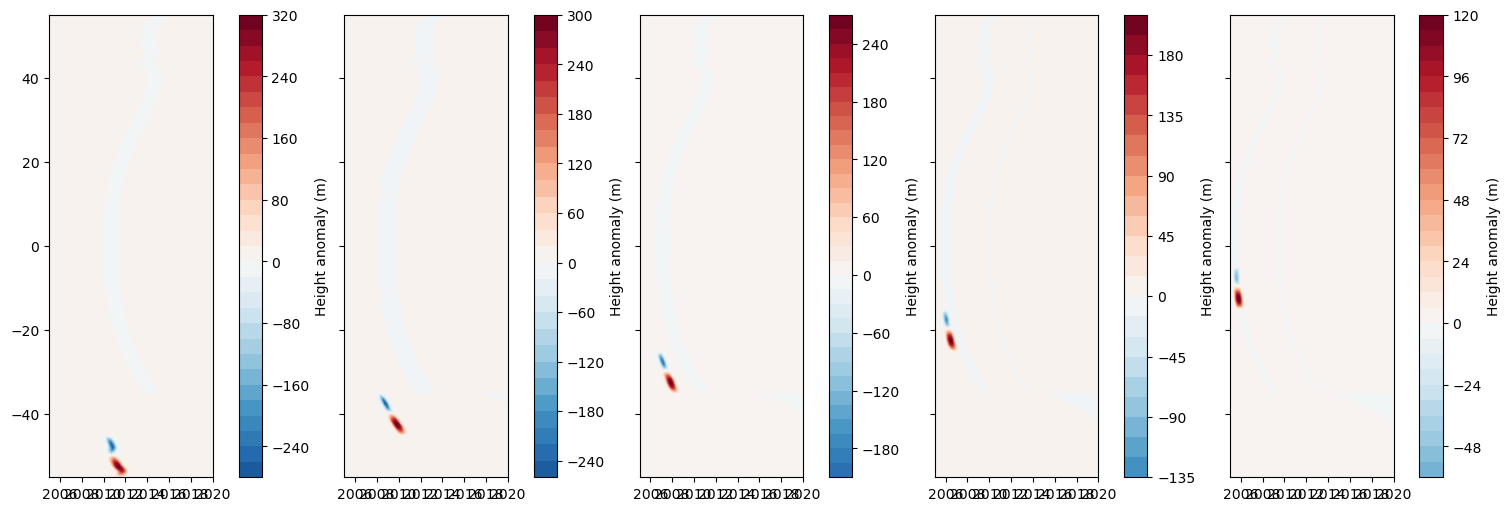

In [9]:
# Plot the solutions in a single figure
fig, axs = plt.subplots(nrows=1, ncols=len(h_b_list), figsize=(15, 5), constrained_layout=True, sharey=True)
for ax, h_b in zip(axs, h_b_list):
    ctf = ax.contourf(h_b.time, h_b.latitude, h_b.T, levels=31, cmap="RdBu_r", norm=mpl.colors.CenteredNorm())
    plt.colorbar(ctf, ax=ax, label="Height anomaly (m)")


In [10]:
# Extracting T for each of the bursts
T_list = [solution.T.sel(time=slice(t_0, "2016-01-01")).compute() for solution in solutions]
# Stitch south-to-north; keeping the last duplicate prioritizes the northern region.
atlantic_regions = ["atlantic_pacific", "atlantic_indian", "north_atlantic"]
T_list = [
    xr.concat([T.sel(region=r, drop=True).dropna("latitude", how="all") for r in atlantic_regions], dim="latitude")
    .drop_duplicates("latitude", keep="last").sortby("latitude")
    for T in T_list
]

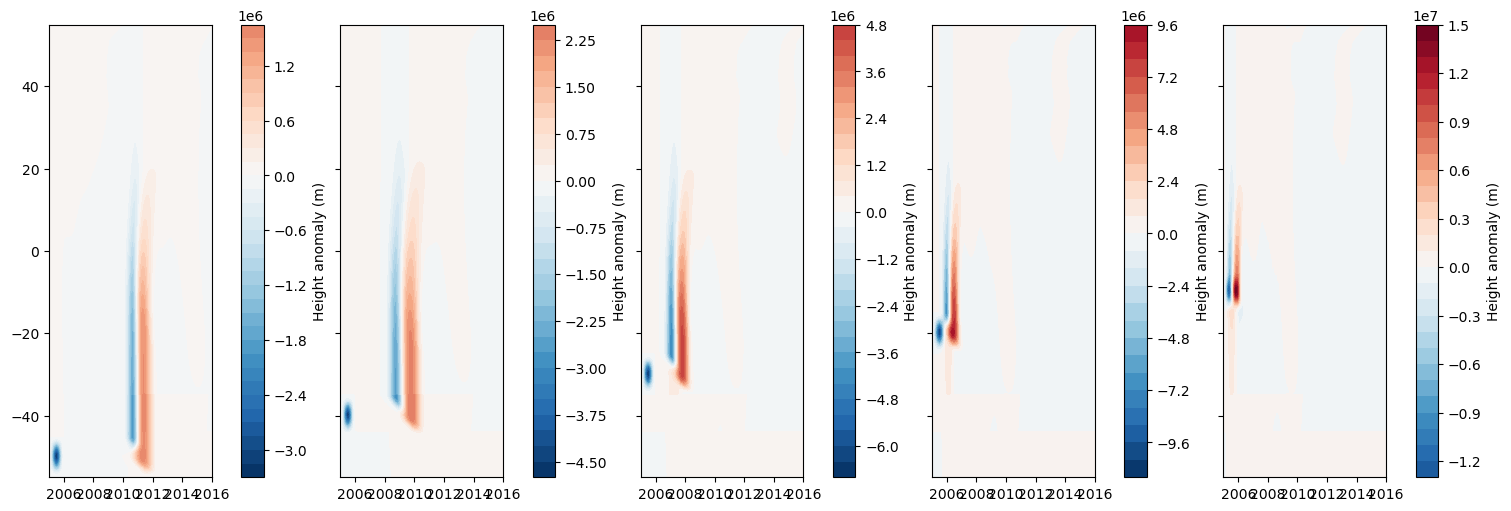

In [11]:
# Plot the solutions in a single figure
fig, axs = plt.subplots(nrows=1, ncols=len(T_list), figsize=(15, 5), constrained_layout=True, sharey=True)
for ax, T in zip(axs, T_list):
    ctf = ax.contourf(T.time, T.latitude, T.T, levels=31, cmap="RdBu_r", norm=mpl.colors.CenteredNorm())
    plt.colorbar(ctf, ax=ax, label="Height anomaly (m)")


This messy plot seems to indicate that the thickness anomaly does not in fact saturate, or at least that it is more complicated than that.